<div align="left">
    <img src="../assets/Qgorithm_logo.png" width="180">
</div>

**Author:** Emad Rezaei Fard Boosari

📺 YouTube: https://youtube.com/@qgorithm

💼 LinkedIn: https://linkedin.com/in/your-linkedin

# Introduction

Grover's Search Algorithm is one of the most famous quantum algorithms.

It provides a quadratic speedup for searching an unstructured database of $N$ items, requiring approximately $O(\sqrt{N})$ queries instead of $O(N)$ classical queries.

In this notebook, we implement Grover's algorithm using Qiskit and analyze how amplitude amplification increases the probability of finding the marked state.

# The Search Problem

Suppose we have four possible states:

$$|00⟩, |01⟩, |10⟩, |11⟩$$

and we want to find the marked state $|11⟩$.

A classical algorithm may need to examine several states before finding the correct answer.

Grover's algorithm exploits quantum superposition and interference to locate the target more efficiently.

# Grover's Algorithm Overview

Grover's algorithm consists of four main steps:

1. Generate the initial state $|\psi_0\rangle = |0\rangle^{\otimes n}$
2. Prepare a uniform superposition $|\psi_1\rangle = H^{\otimes n} |\psi_0\rangle$
3. Repeat $\dfrac{\pi}{4}\sqrt{N}$ times
   - Apply the oracle $R_f$
   - Apply the diffusion operator $R_{\psi}^\perp$
4. Measure the quantum state



## Import Required Qiskit's functions

In [2]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Circuit Visualization Helper

In [3]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=True, initial_state=True)

## Example 1: Searching a Two-Qubit Space
In this example, we search for the marked state |10⟩ among four possible states.

In [4]:
w = '10' # MSB = 1, LSB = 0

In [5]:
n = len(w)                                       # Number of qubits
N = 2**n                                         # Number of all basis states in Hilbert space
iter = int(np.floor((np.pi/4)*np.sqrt(N)))       # Number of Iterations 

In [6]:
# create the quantum circuit
qc = QuantumCircuit(n, n)

# Apply Hadamard to entire Staets
qc.h(range(n))
qc.barrier(label = 'H^2')

# Apply Oracle R_f
qc.x(0)
qc.cz(0,1)
qc.x(0)
qc.barrier(label = 'Oracle')

# Apply Diffuser R_psi
qc.h(range(2))
qc.x(range(2))
qc.cz(0,1)
qc.x(range(2))
qc.h(range(2))
qc.barrier(label = 'diffuser')

# Measurement 
for i in range(n):
    qc.measure(i,i)




display(qplot(qc))

┌───┐ H^2 ┌───┐   ┌───┐ Oracle ┌───┐┌───┐   ┌───┐┌───┐ diffuser ┌─┐   
q_0: |0>┤ H ├──░──┤ X ├─■─┤ X ├───░────┤ H ├┤ X ├─■─┤ X ├┤ H ├────░─────┤M├───
        ├───┤  ░  └───┘ │ └───┘   ░    ├───┤├───┤ │ ├───┤├───┤    ░     └╥┘┌─┐
q_1: |0>┤ H ├──░────────■─────────░────┤ H ├┤ X ├─■─┤ X ├┤ H ├────░──────╫─┤M├
        └───┘  ░                  ░    └───┘└───┘   └───┘└───┘    ░      ║ └╥┘
 c: 0 2/═════════════════════════════════════════════════════════════════╩══╩═
                                                                         0  1

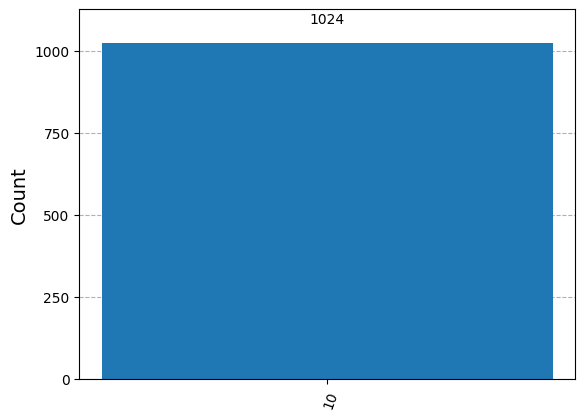

In [7]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Example 2: Searching a Four-Qubit Space
We now extend the same procedure to a larger search space consisting of sixteen basis states.

In [8]:
w = '1100' # MSB = 1, LSB = 0

In [9]:
n = len(w)                                    # Number of qubits
N = 2**n                                      # Number of Basis vectors for 4-qubit system
iter = int(np.floor((np.pi/4)*np.sqrt(N)))    # Number of iteration

## Building the Grover Operator
$$G = H^{\otimes n} R_0^{\perp} H^{\otimes n} R_f$$

In [10]:
cirq = QuantumCircuit(n)

# Apply Oracle
cirq.x(range(2))
cirq.h(-1)
cirq.mcx([i for i in range(n-1)], n-1)
cirq.h(-1)
cirq.x(range(2))
#cirq.barrier(label = 'R_f')

# Apply Diffuser
cirq.h(range(n))
cirq.x(range(n))
#cirq.barrier()
cirq.h(-1)
cirq.mcx([i for i in range(n-1)], n-1)
cirq.h(-1)
#cirq.barrier()
cirq.x(range(n))
cirq.h(range(n))

G = cirq.to_gate()
G.name = 'G'

qplot(cirq)

┌───┐     ┌───┐┌───┐┌───┐          ┌───┐┌───┐     
q_0: |0>┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
        ├───┤  │  ├───┤├───┤├───┤       │  ├───┤├───┤     
q_1: |0>┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
        └───┘  │  ├───┤├───┤└───┘       │  ├───┤├───┤     
q_2: |0>───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────
        ┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐
q_3: |0>┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘

In [11]:
# Creating the quantum Circuit for searching the 'w' staet
qc = QuantumCircuit(n, n)

# Applying Hadamard
qc.h(range(4))
qc.barrier(label = 'H^4')

for i in range(iter):
    qc.append(G, [i for i in range(4)])

qc.barrier(label = 'End of Search')

for i in range(n):
    qc.measure(i,i)

qplot(qc)

┌───┐ H^4 ┌────┐┌────┐┌────┐ End of Search ┌─┐         
q_0: |0>┤ H ├──░──┤0   ├┤0   ├┤0   ├───────░───────┤M├─────────
        ├───┤  ░  │    ││    ││    │       ░       └╥┘┌─┐      
q_1: |0>┤ H ├──░──┤1   ├┤1   ├┤1   ├───────░────────╫─┤M├──────
        ├───┤  ░  │  G ││  G ││  G │       ░        ║ └╥┘┌─┐   
q_2: |0>┤ H ├──░──┤2   ├┤2   ├┤2   ├───────░────────╫──╫─┤M├───
        ├───┤  ░  │    ││    ││    │       ░        ║  ║ └╥┘┌─┐
q_3: |0>┤ H ├──░──┤3   ├┤3   ├┤3   ├───────░────────╫──╫──╫─┤M├
        └───┘  ░  └────┘└────┘└────┘       ░        ║  ║  ║ └╥┘
 c: 0 4/════════════════════════════════════════════╩══╩══╩══╩═
                                                    0  1  2  3

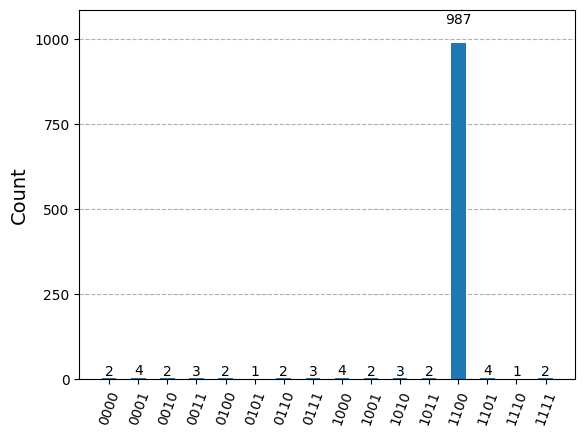

In [12]:
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Conclusion

In this notebook we:

- Introduced the search problem
- Built Grover's oracle
- Constructed the diffusion operator
- Implemented Grover's algorithm using Qiskit
- Observed the amplification of the marked state

In the next notebook, we will study multiple marked states and the connection between Grover's search and amplitude amplification.